# Proyek Analisis Data: [Bike Sharing]
- **Nama:** [Ghina Roudlotul Jannah]
- **Email:** [roudlotuljannah@mhs.unsoed.ac.id]
- **ID Dicoding:** [CDCC229D6X1438]

## Menentukan Pertanyaan Bisnis

- Bagaimana performa penyewaan sepeda dalam beberapa bulan terakhir dan apakah terjadi peningkatan dari tahun 2011 ke 2012?
- Pada musim dan kondisi cuaca apa penyewaan sepeda paling tinggi dan paling rendah selama periode 2011-2012?
- Pada jam dan hari apa pengguna paling sering melakukan penyewaan sepeda selama periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

## Data Wrangling

### Gathering Data

In [4]:
# Memuat dataset per hari (day.csv) dan menampilkan 5 baris pertama
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset day.csv berhasil dimuat dengan 16 kolom dan data dimulai dari tanggal 1 Januari 2011
- Dari 5 baris pertama terlihat data berada di musim 1 (Spring), tahun 0 (2011), bulan 1 (Januari)
- Kondisi cuaca (weathersit) bernilai 2 di beberapa hari awal, menunjukkan cuaca berkabut di awal tahun
- Total penyewaan (cnt) di 5 hari awal Januari berkisar antara 801-1600 per hari, dengan pengguna registered jauh lebih dominan dibanding casual

In [5]:
# Memuat dataset per jam (hour.csv) dan menampilkan 5 baris pertama
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset hour.csv berhasil dimuat dengan 17 kolom, bertambah kolom hr dibanding day.csv
- Dari 5 baris pertama terlihat data jam 00.00-04.00 dini hari tanggal 1 Januari 2011
- Penyewaan di dini hari sangat rendah (cnt:1-40), wajar karena jam tersebut mayoritas orang tidur
- Kecepatan angin (windspeed) bernilai di 0,0 di jam dini hari, menunjukkan kondisi tenang di malam hari

### Assessing Data

**Menilai tabel day.csv**

In [6]:
# Melihat struktur dan tipe data pada dataset
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:**
- Dataset terdiri dari 731 baris dan 16 kolom
- Kolom dteday perlu diubah dari object menjadi datetime agar bisa diolah untuk analisis waktu
- Kolom season, weathersit, weekday perlu diubah dari int menjadi kategori dan diubah menjadi label nama dari masing masing kategori
- Kolom cuaca (temp, atemp, hum, windspeed) sudah bertipe float hal ini sudah tepat
- Semua perubahan tipe data akan ditangani di tahap data cleaning

In [7]:
# Menghitung jumlah missing values di setiap kolom
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Insight:**
- Dataset day.csv lengkap tanpa missing values pada seluruh 16 kolom (731 baris), sehingga tidak diperlukan penanganan missing values di tahap cleaning

In [8]:
# Mengecek jumlah baris duplikat
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Dataset day.csv tidak memiliki duplikat, wajar karena setiap baris merepresentasikan 1 hari unik

In [9]:
# Mengecek jumlah nilai unik di setiap kolom
day_df.nunique()

,0
instant,731
dteday,731
season,4
yr,2
mnth,12
holiday,2
weekday,7
workingday,2
weathersit,3
temp,499


**Insight:**
- Data mencakup 731 hari unik tanpa duplikat
- Kolom kategori (season, yr, mnth, weekday) sudah sesuai dokumentasi
- Kolom weathersit hanya memiliki 3 nilai unik (seharusnya 4) sehingga perlu dicek lebih lanjut
- Kolom kontinu (temp, atemp, hum, windspeed) wajar memiliki banyak nilai unik

In [10]:
# Mengecek nilai unik pada kolom weathersit
print(day_df['weathersit'].unique())

[2 1 3]


**Insight:**
- Kolom weathersit hanya memiliki 3 nilai unik (1,2,3), nilai 4 (heavy rain/snow) tidak pernah muncul, artinya selama 2011–2012 di Washington D.C. tidak terjadi cuaca ekstrem

In [11]:
# Menampilkan statistik deskriptif kolom numerik
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Rata-rata penyewaan harian ±4504 unit (casual ±848, registered ±3656) menunjukkan pengguna registered jauh lebih dominan
- Penyewaan terendah 22 unit, tertinggi 8714 unit merupakan gap sangat besar menunjukkan pengaruh musim/cuaca signifikan
- Humidity memiliki min = 0 sehingga perlu dicek, kemungkinan anomali atau hari tanpa pencatatan
- Kolom weathersit max = 3, konsisten dengan temuan sebelumnya (tidak ada cuaca ekstrem)
- Suhu (temp & atemp) berkisar 0.06–0.86 dalam skala normalisasi, menunjukkan variasi musim yang cukup besar

In [12]:
# Mengecek baris dengan nilai kelembaban (hum) = 0
day_df[day_df['hum'] == 0]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
68,69,2011-03-10,1,0,3,0,4,1,3,0.389091,0.385668,0.0,0.261877,46,577,623


**Insight:**
- Nilai hum = 0 ditemukan pada 10 Maret 2011, dipastikan merupakan error karena pada hari tersebut cuaca tercatat light rain/snow (weathersit = 3) yang seharusnya memiliki kelembaban tinggi, namun penyewaan tetap normal (623 sepeda). Nilai ini akan diperbaiki di tahap cleaning

**Menilai tabel hour.csv**

In [13]:
# Melihat struktur dan tipe data pada dataset
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Insight:**
- Dataset hour.csv memiliki 17.379 baris dan 17 kolom, lebih banyak dari day.csv karena setiap hari memiliki 24 jam pencatatan
- Terdapat tambahan kolom hr (jam 0–23) dibanding day.csv
- Kolom dteday perlu diubah dari object menjadi datetime
- Kolom season, weathersit, weekday perlu diubah dari int menjadi kategori
- Kolom cuaca (temp, atemp, hum, windspeed) sudah bertipe float hal ini sudah tepat
- Semua perubahan tipe data akan ditangani di tahap data cleaning

In [14]:
# Menghitung jumlah missing values di setiap kolom
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Insight:**
- Dataset hour.csv lengkap tanpa missing values pada seluruh 17 kolom (17379 baris), sehingga tidak diperlukan penanganan missing values di tahap cleaning

In [15]:
# Mengecek jumlah baris duplikat
print("Jumlah duplikasi: ",hour_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Dataset hour.csv tidak memiliki duplikat, wajar karena setiap baris merepresentasikan 1 jam unik dalam 1 hari tertentu

In [16]:
# Menampilkan statistik deskriptif kolom numerik
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Rata-rata penyewaan per jam ±189 unit (casual ±36, registered ±154) menunjukkan pengguna registered tetap jauh lebih dominan
- Penyewaan terendah 1 unit/jam, tertinggi 977 unit/jam merupakan gap besar menunjukkan pengaruh jam sibuk signifikan
- Weathersit max = 4, berbeda dengan day.csv artinya cuaca ekstrem sempat terjadi di level per jam meski tidak terlihat di agregasi harian
- Hum, atemp, dan windspeed memiliki min = 0 sehingga perlu dicek kemungkinan error seperti pada day.csv

In [17]:
# Menghitung frekuensi setiap kategori cuaca
hour_df['weathersit'].value_counts()

,count
weathersit,
1,11413
2,4544
3,1419
4,3


**Insight:**
- Cuaca cerah (1) paling dominan dengan 11.413 jam disusul dengan cuaca berkabut (2) sebanyak 4.544 jam dan cuaca hujan/salju ringan (3) sebanyak 1.419 jam. Sedangkan cuaca ekstrem (4) hanya 3 jam yaitu sangat jarang, konsisten dengan temuan day.csv yang nilai 4 tidak muncul sama sekali di agregasi harian

In [18]:
# Mengecek baris dengan cuaca heavy rain/snow (weathersit = 4)
hour_df[hour_df['weathersit'] == 4]

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
585,586,2011-01-26,1,0,1,16,0,3,1,4,0.22,0.1970,0.93,0.3284,1,35,36
8854,8855,2012-01-09,1,1,1,18,0,1,1,4,0.20,0.2273,0.86,0.0896,6,158,164
9123,9124,2012-01-21,1,1,1,1,0,6,0,4,0.14,0.1364,0.86,0.1940,1,22,23


**Insight:**
- Hanya terdapat 3 jam dengan cuaca ekstrem (weathersit = 4 / heavy rain/snow) dari total 17.379 data hal tersebut sangat jarang
- Meski cuaca ekstrem, penyewaan tetap terjadi (22–164 unit/jam), menunjukkan bahwa pengguna registered tetap menyewa meski kondisi buruk
- Ketiga baris terjadi di Januari (mnth=1), season 1 yaitu Spring
- Kolom hum tinggi (0.86–0.93) wajar untuk kondisi hujan lebat/salju

In [19]:
# Mengecek jumlah dan detail baris dengan kelembaban ( hum = 0)
print("Jumlah hum = 0: ",(hour_df['hum'] == 0).sum())
hour_df[hour_df['hum'] == 0]

Jumlah hum = 0:  22


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
1551,1552,2011-03-10,1,0,3,0,0,4,1,3,0.34,0.3182,0.0,0.2537,3,0,3
1552,1553,2011-03-10,1,0,3,1,0,4,1,3,0.34,0.3182,0.0,0.2537,0,2,2
1553,1554,2011-03-10,1,0,3,2,0,4,1,3,0.34,0.3182,0.0,0.2537,0,1,1
1554,1555,2011-03-10,1,0,3,5,0,4,1,3,0.36,0.3485,0.0,0.1940,1,2,3
1555,1556,2011-03-10,1,0,3,6,0,4,1,3,0.36,0.3333,0.0,0.3284,0,12,12
1556,1557,2011-03-10,1,0,3,7,0,4,1,3,0.38,0.3939,0.0,0.2239,1,36,37
1557,1558,2011-03-10,1,0,3,8,0,4,1,3,0.38,0.3939,0.0,0.2836,1,43,44
1558,1559,2011-03-10,1,0,3,9,0,4,1,3,0.40,0.4091,0.0,0.2239,1,23,24
1559,1560,2011-03-10,1,0,3,10,0,4,1,3,0.40,0.4091,0.0,0.1642,0,17,17
1560,1561,2011-03-10,1,0,3,11,0,4,1,3,0.40,0.4091,0.0,0.2537,6,5,11


**Insight:**
- Ditemukan 22 baris dengan hum = 0, semuanya terjadi pada 10 Maret 2011 mencakup jam 0–23 (seharian penuh). Cuaca tercatat weathersit = 3 (light rain/snow) yang seharusnya memiliki kelembaban tinggi, sehingga nilai 0 dipastikan error sensor/pencatatan bukan kondisi nyata. Seluruh 22 baris ini perlu diperbaiki di tahap cleaning

In [20]:
# Mengecek jumlah dan detail baris dengan suhu terasa (atemp = 0)
print("Jumlah atemp = 0: ",(hour_df['atemp'] == 0).sum())
hour_df[hour_df['atemp'] == 0]

Jumlah atemp = 0:  2


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
480,481,2011-01-22,1,0,1,1,0,6,0,2,0.04,0.0,0.41,0.3881,3,9,12
486,487,2011-01-22,1,0,1,8,0,6,0,1,0.02,0.0,0.44,0.3284,1,26,27


**Insight:**
- Ditemukan 2 baris dengan atemp = 0 pada 22 Januari 2011 (jam 1 dan jam 8). Nilai temp pada kedua baris sangat rendah (0.02–0.04) namun tidak nol meski di bulan Januari season 1 (spring), suhu serendah itu masih mungkin terjadi, tetapi atemp yang tepat 0 tidak wajar karena seharusnya mendekati nilai temp. Nilai ini dipastikan error pencatatan dan perlu diperbaiki di tahap cleaning

In [21]:
# Mengecek jumlah dan detail baris dengan kecepatan angin (windspeed = 0)
print("Jumlah windspeed = 0: ",(hour_df['windspeed'] == 0).sum())
hour_df[hour_df['windspeed'] == 0]

Jumlah windspeed = 0:  2180


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17319,17320,2012-12-29,1,1,12,12,0,6,0,3,0.20,0.2424,1.00,0.0,5,43,48
17320,17321,2012-12-29,1,1,12,13,0,6,0,3,0.20,0.2424,1.00,0.0,13,71,84
17322,17323,2012-12-29,1,1,12,15,0,6,0,2,0.24,0.2424,0.87,0.0,19,110,129
17330,17331,2012-12-29,1,1,12,23,0,6,0,2,0.26,0.2424,0.60,0.0,0,32,32


**Insight:**
- Ditemukan 2.180 baris dengan windspeed = 0 jumlah yang sangat banyak (±12,5% dari total data). Tidak wajar jika angin benar-benar 0 dalam jumlah sebesar itu, sehingga kemungkinan besar merupakan error pencatatan/sensor. Nilai ini perlu diimputasi

### Cleaning Data

**Membersihkan tabel day_df**

In [22]:
# Menghapus kolom instant karena hanya berupa ID yang tidak diperlukan
day_df.drop(columns="instant", inplace=True)

**Insight:**
- Kolom instant berhasil dihapus karena hanya berfungsi sebagai nomor urut (ID) yang tidak memiliki nilai analitis

In [23]:
# Mengonversi kolom dteday dari tipe data object menjadi tipe data datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

**Insight:**
- Kolom dteday berhasil dikonversi dari tipe object menjadi datetime, memungkinkan operasi berbasis waktu

In [24]:
# Membuat mapping dari angka musim (1-4) menjadi nama musim (Spring, Fall, dll) & mengubah ke tipe data kategorikal
season_map = {1:'Spring',2:'Summer',3:'Fall',4:'Winter'}

# Menentukan urutan kategori musim dari Spring sampai Winter (ordered)
season_order = CategoricalDtype(
    categories=['Spring','Summer','Fall','Winter'], ordered=True)

# Mengubah angka musim menjadi nama musim & mengubah ke tipe data kategorikal
day_df['season'] = day_df['season'].map(season_map).astype('category')

**Insight:**
- Kolom season berhasil dikonversi dari kode numerik (1–4) menjadi label yang mudah dibaca: Spring, Summer, Fall, Winter
- Tipe data diubah menjadi category untuk efisiensi memori dan kemudahan interpretasi dalam visualisasi
- Urutan kategori ditetapkan secara ordered (Spring hingga Winter) agar analisis musiman dapat dilakukan dengan benar

In [25]:
# Membuat mapping dari angka cuaca menjadi deskripsi (Clear, Mist, dll) & mengubah ke tipe data kategorikal
weather_map = {1:'Clear',2:'Mist',3:'Light Rain/Snow',4:'Heavy Rain/Snow'}

#  Menentukan urutan kategori cuaca dari Clear sampai Heavy Rain/Snow
weather_order = CategoricalDtype(
    categories=['Clear','Mist','Light/Snow','Heavy Rain/Snow'], ordered=True)

# Mengubah angka cuaca menjadi nama cuaca & mengubah ke tipe data kategorikal
day_df['weathersit'] = day_df['weathersit'].map(weather_map).astype('category')

**Insight:**
- Kolom weathersit berhasil dikonversi dari kode numerik (1–4) menjadi label deskriptif: Clear, Mist, Light Rain/Snow, Heavy Rain/Snow
- Tipe data diubah menjadi category untuk mempermudah visualisasi dan pengelompokan berdasarkan kondisi cuaca
- Urutan kategori ditetapkan dari kondisi terbaik (Clear) hingga terburuk (Heavy Rain/Snow)

In [26]:
# Mengubah kode tahun (0 dan 1) menjadi label tahun (2011 dan 2012) & mengubah ke tipe data kategorikal
year_map = {0:'2011',1:'2012'}
day_df['yr'] = day_df['yr'].map(year_map).astype('category')

**Insight:**
- Kolom yr berhasil dikonversi dari kode biner (0 dan 1) menjadi label tahun yang jelas: 2011 dan 2012

In [27]:
# Membuat mapping dari angka hari (0-6) ke nama hari (Sun-Sat)
weekday_map = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}

# Menentukan urutan kategori hari dari Minggu sampai Sabtu (ordered)
weekday_order = CategoricalDtype(
    categories=['Sun','Mon','Tue','Wed','Thu','Fri','Sat'], ordered=True)

# Mengubah angka hari menjadi nama hari & mengubah ke tipe data kategorikal
day_df['weekday'] = day_df['weekday'].map(weekday_map).astype(weekday_order)

**Insight:**
- Kolom weekday berhasil dikonversi dari kode numerik (0–6) menjadi nama hari (Sun–Sat) dengan urutan ordered yang benar
- Tipe category dengan ordered=True memastikan hari ditampilkan secara kronologis (Sunday hingga Saturday) pada grafik dan groupby

In [28]:
# Membuat mapping dari angka bulan (1–12) ke nama bulan (Jan-Dec)
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

# Menentukan urutan kategori bulan dari Januari hingga Desember (ordered)
month_order = CategoricalDtype(
    categories=['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec'], ordered=True)

# Mengubah angka bulan menjadi nama bulan & mengubah ke tipe data kategorikal
day_df['mnth'] = day_df['mnth'].map(month_map).astype(month_order)

**Insight:**
- Kolom mnth berhasil dikonversi dari angka (1–12) menjadi nama bulan (Jan–Dec) dengan urutan ordered yang tepat
- Penggunaan CategoricalDtype dengan urutan January hingga December memastikan tampilan kronologis yang benar pada visualisasi

In [29]:
# Melihat struktur dan tipe data pada dataset
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[ns]
 1   season      731 non-null    category      
 2   yr          731 non-null    category      
 3   mnth        731 non-null    category      
 4   holiday     731 non-null    int64         
 5   weekday     731 non-null    category      
 6   workingday  731 non-null    int64         
 7   weathersit  731 non-null    category      
 8   temp        731 non-null    float64       
 9   atemp       731 non-null    float64       
 10  hum         731 non-null    float64       
 11  windspeed   731 non-null    float64       
 12  casual      731 non-null    int64         
 13  registered  731 non-null    int64         
 14  cnt         731 non-null    int64         
dtypes: category(5), datetime64[ns](1), float64(4), int64(5)
memory usage: 62.0

**Insight:**
- Berdasarkan hasil day_df.info(), seluruh kolom telah memiliki tipe data yang sesuai dengan karakteristiknya:
  - Tipe datetime pada dteday untuk analisis berbasis waktu
  - Tipe category pada variabel seperti season, mnth, weekday, dan weathersit untuk mempermudah interpretasi dan visualisasi
  - Tipe integer pada holiday dan workingday (biner 0/1)
  - Tipe numerik pada variabel seperti temp, atemp, hum, windspeed, dan cnt
- Tidak terdapat missing values pada dataset, sehingga data secara umum dalam kondisi lengkap

In [30]:
# Melihat ringkasan statistik seluruh kolom dalam dataset
day_df.describe(include='all')

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731,731,731,731,731.000000,731,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,4,2,12,NaN,7,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,2012,Jan,NaN,Sun,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,188,366,62,NaN,105,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-01 00:00:00,NaN,NaN,NaN,0.028728,NaN,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,2011-07-02 12:00:00,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,2012-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,2012-07-01 12:00:00,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,2012-12-31 00:00:00,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Musim Fall paling dominan dengan 188 hari sedangkan kondisi cuaca didominasi oleh Clear (463 hari) artinya mayoritas hari memiliki cuaca baik
- Hari kerja (workingday) lebih banyak dibanding non-working day, sedangkan hari libur sangat sedikit
- Rata-rata suhu (temp) sekitar 0.49, dengan variasi cukup besar (0.05 – 0.86)
- Kelembapan (hum) cenderung tinggi (0.63), sedangkan windspeed relatif rendah (0.19)
- Rata-rata penyewaan 4.504 sepeda/hari dengan registered (±3.656) jauh lebih dominan dari casual (±848)
- Penyewaan tertinggi 8.714/hari, terendah 22/hari merupakan gap besar menunjukkan pengaruh musim & cuaca signifikan
- Perbedaan besar pada jumlah penyewaan mengindikasikan adanya pengaruh faktor eksternal misalnya musim, cuaca, hari kerja vs libur

In [31]:
# Mengganti nilai 0 pada kolom hum dengan median bulan yang sama untuk mengatasi data tidak valid
day_df.loc[day_df['hum'] == 0, 'hum'] = day_df.groupby('mnth', observed=True)['hum'].transform('median')[day_df['hum'] == 0]

**Insight:**
- Nilai hum = 0 pada 10 Maret 2011 berhasil diganti dengan nilai median kelembaban bulan yang sama (Maret). Penggunaan median per bulan dipilih karena lebih robust terhadap outlier dibandingkan mean, sehingga nilai imputasi lebih representatif terhadap kondisi kelembaban normal di bulan tersebut

In [32]:
# Melihat ringkasan statistik seluruh kolom dalam dataset
day_df.describe(include='all')

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731,731,731,731,731.000000,731,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,4,2,12,NaN,7,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,2012,Jan,NaN,Sun,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,188,366,62,NaN,105,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-01 00:00:00,NaN,NaN,NaN,0.028728,NaN,0.683995,NaN,0.495385,0.474354,0.628688,0.190486,848.176471,3656.172367,4504.348837
min,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,2011-07-02 12:00:00,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,2012-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,2012-07-01 12:00:00,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,2012-12-31 00:00:00,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Setelah imputasi, nilai minimum hum pada day_df tidak lagi bernilai 0, mengonfirmasi bahwa anomali data telah berhasil diperbaiki
- Statistik deskriptif lainnya (mean, median, std) tidak mengalami perubahan signifikan karena hanya 1 baris yang diimputasi dari total 731 baris
- Dataset day_df kini bersih dan siap digunakan untuk tahap Exploratory Data Analysis (EDA)

**Membersihkan tabel hour_df**

In [33]:
# Menghapus kolom instant karena hanya berupa ID yang  tidak diperlukan
hour_df.drop(columns="instant", inplace=True)

**Insight:**
- Kolom instant berhasil dihapus dari hour_df, konsisten dengan pembersihan yang dilakukan pada day_df

In [34]:
# Mengonversi kolom dteday dari tipe data object menjadi tipe data datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

**Insight:**
- Kolom dteday berhasil dikonversi dari tipe object menjadi datetime, memungkinkan operasi berbasis waktu

In [35]:
# Membuat mapping dari angka musim (1-4) menjadi nama musim (Spring, Fall, dll) & mengubah ke tipe data kategorikal
season_map = {1:'Spring',2:'Summer',3:'Fall',4:'Winter'}

# Menentukan urutan kategori musim dari Spring sampai Winter (ordered)
season_order = CategoricalDtype(
    categories=['Spring','Summer','Fall','Winter'], ordered=True)

# Mengubah angka musim menjadi nama musim & mengubah ke tipe data kategorikal
hour_df['season'] = hour_df['season'].map(season_map).astype('category')

**Insight:**
- Kolom season pada hour_df berhasil dikonversi ke label musim yang readable (Spring, Summer, Fall, Winter) dengan tipe category

In [36]:
# Membuat mapping dari angka cuaca menjadi deskripsi (Clear, Mist, dll) & mengubah ke tipe data kategorikal
weather_map = {1:'Clear',2:'Mist',3:'Light Rain/Snow',4:'Heavy Rain/Snow'}

#  Menentukan urutan kategori cuaca dari Clear sampai Heavy Rain/Snow
weather_order = CategoricalDtype(
    categories=['Clear','Mist','Light/Snow','Heavy Rain/Snow'], ordered=True)

# Mengubah angka cuaca menjadi nama cuaca & mengubah ke tipe data kategorikal
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map).astype('category')

**Insight:**
- Kolom weathersit pada hour_df berhasil dikonversi ke label deskriptif cuaca dengan tipe category

In [37]:
# Mengubah kode tahun (0 dan 1) menjadi label tahun (2011 dan 2012) & mengubah ke tipe data kategorikal
year_map = {0:'2011',1:'2012'}
hour_df['yr'] = hour_df['yr'].map(year_map).astype('category')

**Insight:**
- Kolom yr pada hour_df berhasil dikonversi dari kode biner ke label tahun 2011/2012, konsisten dengan day_df

In [38]:
# Membuat mapping dari angka hari (0-6) ke nama hari (Sun-Sat)
weekday_map = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}

# Menentukan urutan kategori hari dari Minggu sampai Sabtu (ordered)
weekday_order = CategoricalDtype(
    categories=['Sun','Mon','Tue','Wed','Thu','Fri','Sat'], ordered=True)

# Mengubah angka hari menjadi nama hari & mengubah ke tipe data kategorikal
hour_df['weekday'] = hour_df['weekday'].map(weekday_map).astype(weekday_order)

**Insight:**
- Kolom weekday pada hour_df berhasil dikonversi ke nama hari dengan urutan ordered Sunday hingga Saturday

In [39]:
# Membuat mapping dari angka bulan (1–12) ke nama bulan (Jan-Dec)
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

# Menentukan urutan kategori bulan dari Januari hingga Desember (ordered)
month_order = CategoricalDtype(
    categories=['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec'], ordered=True)

# Mengubah angka bulan menjadi nama bulan & mengubah ke tipe data kategorikal
hour_df['mnth'] = hour_df['mnth'].map(month_map).astype(month_order)

**Insight:**
- Kolom mnth pada hour_df berhasil dikonversi ke nama bulan Jan–Dec dengan urutan ordered, konsisten dengan day_df

In [40]:
# Mengonversi kolom hour dari tipe data object menjadi tipe data kategori
hour_df['hr'] = hour_df['hr'].astype('category')

**Insight:**
- Kolom hr berhasil dikonversi dari integer ke tipe category untuk merepresentasikan 24 jam dalam sehari (0–23)

In [41]:
# Melihat struktur dan tipe data pada dataset
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17379 non-null  datetime64[ns]
 1   season      17379 non-null  category      
 2   yr          17379 non-null  category      
 3   mnth        17379 non-null  category      
 4   hr          17379 non-null  category      
 5   holiday     17379 non-null  int64         
 6   weekday     17379 non-null  category      
 7   workingday  17379 non-null  int64         
 8   weathersit  17379 non-null  category      
 9   temp        17379 non-null  float64       
 10  atemp       17379 non-null  float64       
 11  hum         17379 non-null  float64       
 12  windspeed   17379 non-null  float64       
 13  casual      17379 non-null  int64         
 14  registered  17379 non-null  int64         
 15  cnt         17379 non-null  int64         
dtypes: category(6), dateti

**Insight:**
- Berdasarkan hasil hour_df.info(), seluruh kolom telah memiliki tipe data yang sesuai:
  - Tipe datetime pada dteday untuk analisis berbasis waktu
  - Tipe category pada variabel seperti season, mnth, weekday, weathersit, dan hr
  - Tipe integer pada holiday dan workingday (biner 0/1)
  - Tipe numerik pada variabel seperti temp, atemp, hum, windspeed, dan cnt
- Tidak terdapat missing values pada dataset, sehingga data secara umum dalam kondisi lengkap

In [42]:
# Melihat ringkasan statistik seluruh kolom dalam dataset
hour_df.describe(include='all')

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379,17379,17379,17379,17379.0,17379.000000,17379,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,4,2,12,24.0,NaN,7,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,2012,Jul,16.0,NaN,Sat,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4496,8734,1488,730.0,NaN,2512,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,NaN,0.028770,NaN,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-04 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,2012-01-02 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,2012-07-02 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Statistik deskriptif hour_df menunjukkan kondisi dataset sebelum imputasi nilai anomali:
  - Nilai hum min = 0 menandakan masih ada anomali yang akan diperbaiki
  - Nilai atemp min = 0 menandakan masih ada anomali yang akan diperbaiki
  - Nilai windspeed min = 0 dengan frekuensi tinggi menandakan banyak nilai tidak valid
- Rata-rata cnt per jam ≈ 189 unit, dengan median 142, menunjukkan distribusi yang right-skewed akibat jam-jam puncak penyewaan

In [43]:
# Menampilkan 5 baris pertama dari dataset
hour_df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,Spring,2011,Jan,0,0,Sat,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,Spring,2011,Jan,1,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,Spring,2011,Jan,2,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,Spring,2011,Jan,3,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,Spring,2011,Jan,4,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Lima baris pertama hour_df menampilkan data jam 00.00–04.00 tanggal 1 Januari 2011
- Seluruh label kolom kini tampil dalam format yang mudah dibaca (Spring, Clear, 2011, Mon, Jan, dll.) berkat transformasi tipe data yang telah dilakukan
- Penyewaan di dini hari sangat rendah (1–13 unit/jam), konsisten dengan temuan pada tahap Assessing Data

In [44]:
# Mengganti nilai 0 pada kolom hum dengan median bulan & jam yang sama untuk mengatasi data tidak valid
hour_df.loc[hour_df['hum'] == 0, 'hum'] = hour_df.groupby(['mnth', 'hr'], observed=True)['hum'].transform('median')[hour_df['hum'] == 0]

# Mengecek jumlah nilai hum yang masih bernilai 0 setelah proses penggantian
print("hum = 0 :", (hour_df['hum'] == 0).sum())

hum = 0 : 0


**Insight:**
- Nilai hum = 0 pada 22 baris di 10 Maret 2011 berhasil diimputasi menggunakan median kelembaban per kombinasi bulan & jam yang sama. Pendekatan ini lebih akurat karena memperhitungkan variasi kelembaban antar jam dalam hari yang sama

In [45]:
# Mengganti nilai 0 pada kolom atemp dengan nilai temp yang sama untuk mengatasi data tidak valid
hour_df.loc[hour_df['atemp'] == 0, 'atemp'] = hour_df.loc[hour_df['atemp'] == 0, 'temp']

# Mengecek jumlah nilai atemp yang masih bernilai 0 setelah proses penggantian
print("atemp = 0 :", (hour_df['atemp'] == 0).sum())

atemp = 0 : 0


**Insight:**
- Nilai atemp = 0 pada 2 baris di 22 Januari 2011 (jam 1 & jam 8) berhasil diganti dengan nilai temp pada baris yang sama. Pendekatan ini wajar karena atemp seharusnya mendekati nilai temp, terutama di suhu sangat rendah

In [46]:
# Mengganti nilai 0 pada kolom windspeed dengan median bulan & jam yang sama untuk mengatasi data tidak valid
hour_df.loc[hour_df['windspeed'] == 0, 'windspeed'] = hour_df.groupby(['mnth', 'hr'], observed=True)['windspeed'].transform('median')[hour_df['windspeed'] == 0]

# Mengecek jumlah nilai windspeed yang masih bernilai 0 setelah proses penggantian
print("windspeed = 0 :", (hour_df['windspeed'] == 0).sum())

windspeed = 0 : 0


**Insight:**
- Nilai windspeed = 0 yang berjumlah 2.180 baris berhasil diimputasi menggunakan median kecepatan angin per kombinasi bulan & jam. Setelah imputasi, tidak ada lagi nilai 0 yang tidak wajar, memastikan kualitas data untuk analisis berikutnya

In [47]:
# Melihat ringkasan statistik seluruh kolom dalam dataset
hour_df.describe(include='all')

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379,17379,17379,17379,17379.0,17379.000000,17379,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,4,2,12,24.0,NaN,7,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,2012,Jul,16.0,NaN,Sat,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4496,8734,1488,730.0,NaN,2512,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,NaN,0.028770,NaN,0.682721,NaN,0.496987,0.475779,0.627935,0.210981,35.676218,153.786869,189.463088
min,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.020000,0.015200,0.080000,0.089600,0.000000,0.000000,1.000000
25%,2011-07-04 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.340000,0.333300,0.480000,0.134300,4.000000,34.000000,40.000000
50%,2012-01-02 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,2012-07-02 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Setelah imputasi, nilai minimum hum, atemp, dan windspeed pada hour_df tidak lagi bernilai 0, mengonfirmasi bahwa seluruh anomali data telah berhasil diperbaiki
- Statistik deskriptif lainnya (mean, median, std) tidak mengalami perubahan signifikan karena jumlah baris yang diimputasi sangat kecil dibanding total 17.379 baris
- Dataset hour_df kini bersih dan siap digunakan untuk tahap Exploratory Data Analysis (EDA)

In [48]:
# Menyimpan data bersih
day_df.to_csv("day_clean.csv",index=False)
hour_df.to_csv("hour_clean.csv",index=False)

**Insight:**
- Menyimpan data day_df dan hour_df yang telah dibersihkan untuk kepentingan membuat dashboard

## Exploratory Data Analysis (EDA)

### Explore day_df

In [49]:
# Menampilkan 5 baris pertama dari dataset
day_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,Spring,2011,Jan,0,Sat,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,Spring,2011,Jan,0,Sun,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,Spring,2011,Jan,0,Mon,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,Spring,2011,Jan,0,Tue,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,Spring,2011,Jan,0,Wed,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Lima baris pertama day_df setelah proses cleaning menampilkan semua label yang sudah terbaca dengan jelas
- Kolom season menunjukkan 'Spring', weathersit menunjukkan 'Mist' atau 'Clear', yr menampilkan '2011', dan hari serta bulan dalam format nama
- Dataset siap untuk eksplorasi lebih mendalam pada tahap EDA

In [50]:
# Melihat ringkasan statistik seluruh kolom dalam dataset
day_df.describe(include='all')

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731,731,731,731,731.000000,731,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,4,2,12,NaN,7,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,2012,Jan,NaN,Sun,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,188,366,62,NaN,105,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-01 00:00:00,NaN,NaN,NaN,0.028728,NaN,0.683995,NaN,0.495385,0.474354,0.628688,0.190486,848.176471,3656.172367,4504.348837
min,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,2011-07-02 12:00:00,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,2012-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,2012-07-01 12:00:00,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,2012-12-31 00:00:00,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Statistik deskriptif day_df pasca cleaning menunjukkan distribusi data yang wajar tanpa anomali ekstrem.
Fall menjadi musim paling dominan (188 hari), sementara Clear mendominasi kondisi cuaca (463 hari)
- Rata-rata suhu (temp ≈ 0.495) berada di tengah skala normalisasi, menunjukkan data mencakup keseluruhan variasi musim
- Nilai hum tidak lagi bernilai 0, membuktikan imputasi berhasil

In [51]:
# Menampilkan statistik deskriptif untuk kolom casual dan registered
day_df[['casual','registered']].describe()

,casual,registered
count,731.000000,731.000000
mean,848.176471,3656.172367
std,686.622488,1560.256377
min,2.000000,20.000000
25%,315.500000,2497.000000
50%,713.000000,3662.000000
75%,1096.000000,4776.500000
max,3410.000000,6946.000000


**Insight:**
- Pengguna registered jauh lebih dominan dibanding casual: rata-rata 3.656 vs 848 per hari
- Nilai maksimum registered (6.946) hampir 2x lebih tinggi dari casual (3.410), menunjukkan basis pengguna tetap yang kuat
- Standar deviasi registered (1.560) jauh lebih besar dibanding casual (687), artinya penyewaan registered lebih bervariasi dan responsif terhadap kondisi hari
- Sementara itu, pengguna kasual memiliki rentang yang sangat lebar (min: 2, max: 3410), yang menunjukkan adanya lonjakan penggunaan pada hari-hari tertentu.


In [52]:
# Menghitung matriks korelasi antar variabel numerik
day_df[['temp','atemp','hum','windspeed','casual','registered','cnt']].corr()

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991702,0.125395,-0.157944,0.543285,0.540012,0.627494
atemp,0.991702,1.000000,0.138803,-0.183643,0.543864,0.544192,0.631066
hum,0.125395,0.138803,1.000000,-0.246638,-0.084657,-0.103482,-0.113351
windspeed,-0.157944,-0.183643,-0.246638,1.000000,-0.167613,-0.217449,-0.234545
casual,0.543285,0.543864,-0.084657,-0.167613,1.000000,0.395282,0.672804
registered,0.540012,0.544192,-0.103482,-0.217449,0.395282,1.000000,0.945517
cnt,0.627494,0.631066,-0.113351,-0.234545,0.672804,0.945517,1.000000


**Insight:**
- Variabel suhu (temp dan atemp) memiliki korelasi positif yang cukup kuat terhadap jumlah peminjaman sepeda (cnt), dengan nilai sekitar 0.62–0.63. Hal ini menunjukkan bahwa semakin tinggi suhu (cuaca hangat), maka jumlah peminjaman sepeda cenderung meningkat
- Variabel kelembapan (hum) memiliki korelasi negatif terhadap jumlah peminjaman (-0.11), meskipun relatif lemah. Ini mengindikasikan bahwa kelembapan tinggi cenderung sedikit menurunkan jumlah penggunaan sepeda
- Kecepatan angin (windspeed) juga menunjukkan korelasi negatif terhadap jumlah peminjaman (-0.23). Artinya, semakin kencang angin, semakin rendah kecenderungan orang menggunakan sepeda
- Pengguna terdaftar (registered) memiliki korelasi yang sangat kuat terhadap total peminjaman (cnt) dengan nilai 0.95. Ini menunjukkan bahwa total penggunaan sepeda sangat didominasi oleh pengguna terdaftar
- Pengguna kasual (casual) juga memiliki korelasi positif terhadap total peminjaman (0.67), namun tidak sekuat pengguna terdaftar
- Korelasi antara casual dan registered sebesar 0.39 menunjukkan hubungan yang lemah hingga sedang, yang berarti kedua tipe pengguna memiliki pola penggunaan yang berbeda
- Variabel temp dan atemp memiliki korelasi yang sangat tinggi (0.99), yang menandakan adanya informasi yang hampir sama antara keduanya


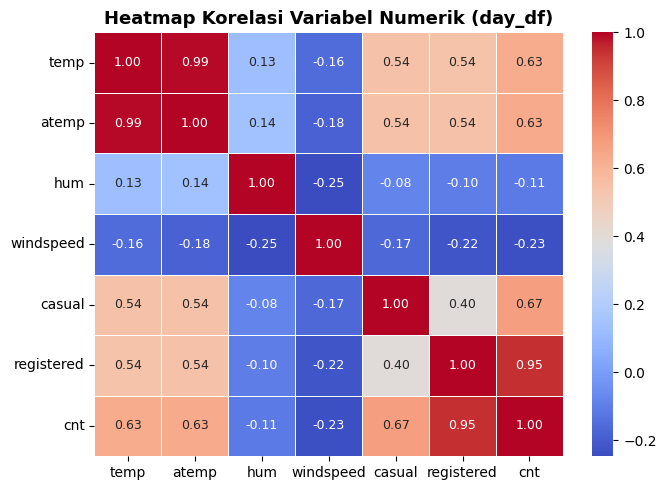

In [53]:
# Visualisasi heatmap korelasi variabel numerik terhadap jumlah penyewaan
plt.figure(figsize=(7, 5))
corr = day_df[['temp','atemp','hum','windspeed','casual','registered','cnt']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})
plt.title('Heatmap Korelasi Variabel Numerik (day_df)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
Seperti yang telah dijelaskan sebelumnya pada tabel korelasi dapat disimpulkan sebagai berikut:
- Secara visual terlihat bahwa variabel suhu (temp dan atemp) memiliki hubungan positif yang konsisten dengan jumlah peminjaman sepeda
- Variabel lingkungan seperti kelembapan (hum) dan kecepatan angin (windspeed) cenderung memiliki hubungan negatif terhadap penggunaan sepeda
- Variabel registered terlihat paling dominan dalam memengaruhi total peminjaman, ditandai dengan warna korelasi yang paling kuat
- Pola korelasi menunjukkan bahwa faktor cuaca dan tipe pengguna merupakan dua aspek utama yang memengaruhi penggunaan layanan bike sharing
- Selain itu, terlihat bahwa temp dan atemp memiliki pola yang hampir identik, mengindikasikan adanya redundansi informasi

In [54]:
# Mengelompokkan data berdasarkan tahun (yr) dan menjumlahkan total penyewaan sepeda (cnt)
yr_total = day_df.groupby('yr', observed=True)['cnt'].sum()
yr_total

,cnt
yr,
2011,1243103
2012,2049576


**Insight:**
- Total penyewaan tahun 2012 (2.049.576) hampir dua kali lipat lebih tinggi dibanding tahun 2011 (1.243.103)
- Pertumbuhan sebesar ≈ 65% dari 2011 ke 2012 menunjukkan tren kenaikan permintaan layanan bike sharing yang sangat signifikan
- Hal ini bisa dipicu oleh meningkatnya kesadaran masyarakat akan transportasi ramah lingkungan dan ekspansi layanan

In [55]:
# Mengelompokkan data berdasarkan bulan (mnth) dan menghitung rata-rata jumlah penyewaan sepeda (cnt)
month_avg = day_df.groupby('mnth', observed=True)['cnt'].mean()
month_avg

,cnt
mnth,
Jan,2176.338710
Feb,2655.298246
Mar,3692.258065
Apr,4484.900000
May,5349.774194
Jun,5772.366667
Jul,5563.677419
Aug,5664.419355
Sep,5766.516667


**Insight:**
- Rata-rata penyewaan harian tertinggi terjadi di bulan Jun–Sep, dengan puncak di bulan September (≈ 5.914 unit/hari)
- Bulan Januari memiliki rata-rata terendah (≈ 2.176 unit/hari), menunjukkan dampak musim dingin yang signifikan terhadap penyewaan
- Pola musiman berbentuk U-terbalik: naik dari Januari hingga puncak di akhir musim panas, kemudian turun menjelang akhir tahun

In [56]:
# Mengelompokkan total penyewaan berdasarkan tahun dan bulan
monthly_trend_df = day_df.groupby(['yr', 'mnth'], observed=True)['cnt'].sum().reset_index()
monthly_trend_df['mnth'] = monthly_trend_df['mnth'].astype(str)
monthly_trend_df

,yr,mnth,cnt
0,2011,Jan,38189
1,2011,Feb,48215
2,2011,Mar,64045
3,2011,Apr,94870
4,2011,May,135821
5,2011,Jun,143512
6,2011,Jul,141341
7,2011,Aug,136691
8,2011,Sep,127418
9,2011,Oct,123511


**Insight:**
- Terjadi peningkatan signifikan jumlah penyewaan sepeda dari tahun 2011 ke 2012 di hampir semua bulan
- Pada tahun 2011, jumlah penyewaan meningkat dari Januari (38.189) hingga mencapai puncak di bulan Juni (143.512), kemudian cenderung menurun hingga Desember
- Pola serupa juga terjadi pada tahun 2012, namun dengan skala yang lebih tinggi, di mana puncak terjadi pada bulan September (218.573)
- Bulan-bulan pertengahan tahun (sekitar Mei–September) secara konsisten menunjukkan jumlah penyewaan tertinggi pada kedua tahun
- Awal tahun (Januari–Februari) dan akhir tahun (November–Desember) cenderung memiliki jumlah penyewaan yang lebih rendah
- Secara keseluruhan, terlihat adanya pola musiman yang konsisten setiap tahun, dengan peningkatan di pertengahan tahun dan penurunan di awal serta akhir tahun.

In [57]:
# Mengelompokkan data berdasarkan musim (season) dan menghitung rata-rata jumlah penyewaan epeda (cnt)
season_avg = day_df.groupby('season', observed=True)['cnt'].mean().reset_index()
season_avg.columns = ['season', 'avg_cnt']
season_avg


,season,avg_cnt
0,Fall,5644.303191
1,Spring,2604.132597
2,Summer,4992.331522
3,Winter,4728.162921


**Insight:**
- Fall (Gugur) memiliki rata-rata penyewaan tertinggi (≈ 5.644 unit/hari), diikuti Summer (≈ 4.992), Winter (≈ 4.728), dan Spring terendah (≈ 2.604)
- Perbedaan yang cukup signifikan antar musim menunjukkan bahwa faktor musiman memiliki pengaruh yang kuat terhadap tingkat penggunaan sepeda
- Tingginya penggunaan pada musim Fall dan Summer mengindikasikan bahwa kondisi lingkungan pada periode tersebut lebih mendukung aktivitas bersepeda
- Rendahnya penggunaan pada musim Spring menunjukkan adanya faktor yang membatasi penggunaan, seperti kondisi cuaca yang belum optimal.

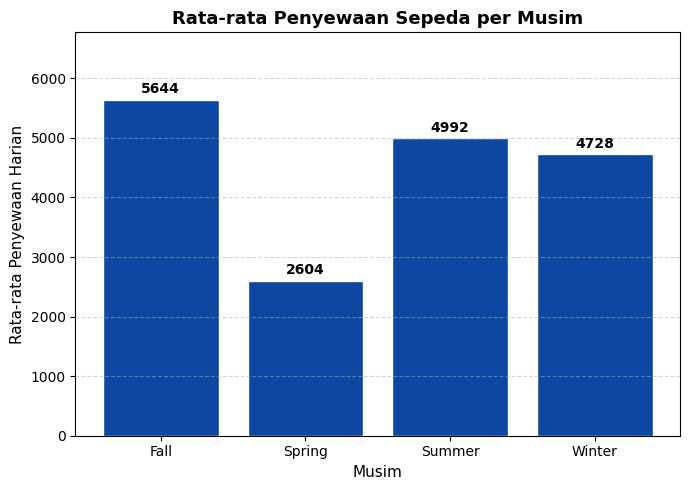

In [58]:
# Visualisasi bar chart rata-rata penyewaan per musim (EDA)
plt.figure(figsize=(7, 5))

bars = plt.bar(
    season_avg['season'],
    season_avg['avg_cnt'],
    color='#0D47A1',
    edgecolor='white'
)

plt.title('Rata-rata Penyewaan Sepeda per Musim', fontsize=13, fontweight='bold')
plt.xlabel('Musim', fontsize=11)
plt.ylabel('Rata-rata Penyewaan Harian', fontsize=11)

for bar, val in zip(bars, season_avg['avg_cnt']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 60,
        f'{val:.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, season_avg['avg_cnt'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**Insight:**
- Musim Fall memiliki rata-rata penyewaan sepeda tertinggi, yaitu sekitar 5644 per hari, menunjukkan periode dengan permintaan paling tinggi
- Musim Spring memiliki rata-rata penyewaan terendah, yaitu sekitar 2604 per hari, yang berarti hanya sekitar setengah dari musim Fall.
- Musim Summer dan Winter berada di tingkat menengah, dengan rata-rata masing-masing sekitar 4992 dan 4728 per hari
- Perbedaan yang cukup signifikan antar musim menunjukkan bahwa faktor musiman memiliki pengaruh yang kuat terhadap tingkat penggunaan sepeda
- Tingginya penggunaan pada musim Fall dan Summer mengindikasikan bahwa kondisi lingkungan pada periode tersebut lebih mendukung aktivitas bersepeda. Sebaliknya, rendahnya penggunaan pada musim Spring menunjukkan adanya faktor yang membatasi penggunaan, seperti kondisi cuaca yang kurang optimal.

In [59]:
# Mengelompokkan data berdasarkan cuaca (weathersit) dan menjumlahkan total penyewaan sepeda (cnt)
weather_total = day_df.groupby('weathersit', observed=True)['cnt'].sum()
weather_total

,cnt
weathersit,
Clear,2257952
Light Rain/Snow,37869
Mist,996858


**Insight:**
- Kondisi cuaca cerah (Clear) mendominasi jumlah penyewaan sepeda dengan total mencapai 2.257.952, jauh lebih tinggi dibandingkan kondisi lainnya
- Pada kondisi kabut (Mist), jumlah penyewaan turun drastis menjadi 99.685, menunjukkan adanya penurunan signifikan dibandingkan cuaca cerah
- Kondisi cuaca buruk seperti hujan ringan atau salju (Light Rain/Snow) memiliki jumlah penyewaan paling rendah, yaitu hanya 37.869
- Perbedaan yang sangat besar antar kondisi cuaca menunjukkan bahwa cuaca merupakan faktor yang sangat berpengaruh terhadap penggunaan layanan bike sharing
- Semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan sepeda, yang mengindikasikan bahwa kenyamanan dan keamanan menjadi pertimbangan utama pengguna.

In [60]:
# Menghitung rata-rata penyewaan per kondisi cuaca
weather_avg = day_df.groupby('weathersit', observed=True)['cnt'].mean().reset_index()
weather_avg.columns = ['weathersit', 'avg_cnt']
weather_avg = weather_avg.sort_values('avg_cnt', ascending=False)
weather_avg

,weathersit,avg_cnt
0,Clear,4876.786177
2,Mist,4035.862348
1,Light Rain/Snow,1803.285714


**Insight:**
- Kondisi cuaca cerah (Clear) memiliki rata-rata penyewaan sepeda tertinggi, yaitu sekitar 4877 per hari
- Pada kondisi berkabut (Mist), rata-rata penyewaan menurun menjadi sekitar 4036 per hari, menunjukkan adanya penurunan dibandingkan cuaca cerah
- Kondisi cuaca buruk seperti hujan ringan atau salju (Light Rain/Snow) memiliki rata-rata penyewaan paling rendah, yaitu sekitar 1803 per hari
- Perbedaan rata-rata yang signifikan antar kondisi cuaca menunjukkan bahwa cuaca memiliki pengaruh yang kuat terhadap tingkat penggunaan sepeda
- Semakin buruk kondisi cuaca, semakin rendah rata-rata penyewaan, yang mengindikasikan bahwa kenyamanan dan keamanan menjadi faktor utama dalam keputusan pengguna
- Pola ini konsisten dengan analisis korelasi yang menunjukkan pengaruh kondisi cuaca terhadap cnt

In [61]:
# Mengelompokkan data berdasarkan hari dalam seminggu (weekday) dan menghitung rata-rata jumlah penyewaan sepeda
weekday_avg_day = day_df.groupby('weekday', observed=True)['cnt'].mean()
weekday_avg_day

,cnt
weekday,
Sun,4228.828571
Mon,4338.123810
Tue,4510.663462
Wed,4548.538462
Thu,4667.259615
Fri,4690.288462
Sat,4550.542857


**Insight:**
- Rata-rata penyewaan sepeda cenderung meningkat dari awal minggu hingga akhir minggu kerja, dengan nilai terendah pada hari Minggu (≈ 4229) dan tertinggi pada hari Jumat (≈ 4690)
- Terlihat adanya tren peningkatan bertahap dari Senin hingga Jumat, yang menunjukkan bahwa penggunaan sepeda lebih tinggi selama hari kerja
- Pada hari Sabtu, rata-rata penyewaan sedikit menurun dibandingkan hari Jumat, namun masih relatif tinggi
- Hari Minggu memiliki rata-rata penyewaan terendah, yang mengindikasikan adanya penurunan aktivitas penggunaan sepeda di akhir pekan
- Pola ini menunjukkan bahwa layanan bike sharing lebih banyak digunakan untuk kebutuhan rutin, seperti transportasi harian (commuting), dibandingkan penggunaan rekreasional

### Explore hour_df

In [62]:
# Menampilkan 5 baris pertama dari dataset
hour_df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,Spring,2011,Jan,0,0,Sat,0,Clear,0.24,0.2879,0.81,0.20895,3,13,16
1,2011-01-01,Spring,2011,Jan,1,0,Sat,0,Clear,0.22,0.2727,0.80,0.17910,8,32,40
2,2011-01-01,Spring,2011,Jan,2,0,Sat,0,Clear,0.22,0.2727,0.80,0.16420,5,27,32
3,2011-01-01,Spring,2011,Jan,3,0,Sat,0,Clear,0.24,0.2879,0.75,0.16420,3,10,13
4,2011-01-01,Spring,2011,Jan,4,0,Sat,0,Clear,0.24,0.2879,0.75,0.13430,0,1,1


**Insight:**
- Lima baris pertama dari dataset hour_df setelah proses cleaning menunjukkan bahwa seluruh label telah terbaca dengan jelas dan konsisten
- Kolom season telah dikonversi menjadi kategori seperti "Spring", kolom weathersit menampilkan kondisi cuaca seperti "Mist" atau "Clear", serta kolom yr, mnth, dan weekday telah ditampilkan dalam format yang lebih mudah dipahami
- Hal ini menunjukkan bahwa proses data cleaning berhasil dilakukan dengan baik, sehingga dataset telah siap untuk digunakan dalam tahap eksplorasi data (EDA) lebih lanjut

In [63]:
# Melihat ringkasan statistik seluruh kolom dalam dataset
hour_df.describe(include='all')

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379,17379,17379,17379,17379.0,17379.000000,17379,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,4,2,12,24.0,NaN,7,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,2012,Jul,16.0,NaN,Sat,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4496,8734,1488,730.0,NaN,2512,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,NaN,0.028770,NaN,0.682721,NaN,0.496987,0.475779,0.627935,0.210981,35.676218,153.786869,189.463088
min,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.020000,0.015200,0.080000,0.089600,0.000000,0.000000,1.000000
25%,2011-07-04 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.340000,0.333300,0.480000,0.134300,4.000000,34.000000,40.000000
50%,2012-01-02 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,2012-07-02 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Statistik deskriptif hour_df pasca cleaning menunjukkan bahwa tidak terdapat nilai yang tidak wajar atau tidak valid pada beberapa variabel numerik seperti hum, atemp, dan windspeed artinya imputasi berhasil
- Rata-rata jumlah penyewaan sepeda per jam adalah sekitar 189 unit, dengan median sebesar 142, yang mengindikasikan distribusi right-skewed akibat adanya nilai tinggi pada jam-jam tertentu
- Nilai maksimum penyewaan mencapai 977 unit per jam, lebih dari 5 kali lipat rata-rata, yang menunjukkan adanya lonjakan permintaan yang signifikan pada jam-jam tertentu (peak hours)

In [64]:
# Menampilkan statistik deskriptif untuk variabel casual dan registered
hour_df[['casual','registered']].describe()

,casual,registered
count,17379.000000,17379.000000
mean,35.676218,153.786869
std,49.305030,151.357286
min,0.000000,0.000000
25%,4.000000,34.000000
50%,17.000000,115.000000
75%,48.000000,220.000000
max,367.000000,886.000000


**Insight:**
- Dominasi pengguna terdaftar (registered) sangat jelas pada level per jam, dengan rata-rata sekitar 154 unit/jam, jauh lebih tinggi dibandingkan pengguna kasual (casual) yang hanya sekitar 36 unit/jam
- Nilai maksimum pengguna terdaftar mencapai 886 unit/jam, hampir 3 kali lipat dibandingkan pengguna kasual yang mencapai 367 unit/jam, menunjukkan bahwa lonjakan penggunaan didominasi oleh pengguna terdaftar
- Meskipun nilai minimum kedua tipe pengguna sama-sama 0, pengguna kasual cenderung lebih sering berada pada nilai rendah, terutama pada jam-jam sepi seperti dini hari
- Perbedaan yang signifikan ini mengindikasikan bahwa pengguna terdaftar cenderung menggunakan sepeda secara rutin (misalnya untuk aktivitas komuter), sedangkan pengguna kasual lebih bersifat situasional

In [65]:
# Menghitung matriks korelasi antar variabel numerik
hour_df[['hr','temp','atemp','hum','windspeed','casual','registered','cnt']].corr()

,hr,temp,atemp,hum,windspeed,casual,registered,cnt
hr,1.000000,0.137603,0.133733,-0.278329,0.141826,0.301202,0.374141,0.394071
temp,0.137603,1.000000,0.987677,-0.072509,-0.035801,0.459616,0.335361,0.404772
atemp,0.133733,0.987677,1.000000,-0.054350,-0.068311,0.454091,0.332558,0.400932
hum,-0.278329,-0.072509,-0.054350,1.000000,-0.315983,-0.351788,-0.278850,-0.328307
windspeed,0.141826,-0.035801,-0.068311,-0.315983,1.000000,0.102697,0.087028,0.100535
casual,0.301202,0.459616,0.454091,-0.351788,0.102697,1.000000,0.506618,0.694564
registered,0.374141,0.335361,0.332558,-0.278850,0.087028,0.506618,1.000000,0.972151
cnt,0.394071,0.404772,0.400932,-0.328307,0.100535,0.694564,0.972151,1.000000


**Insight:**
- Variabel waktu (hr) memiliki korelasi positif terhadap jumlah penyewaan (cnt) sebesar 0.39, yang menunjukkan bahwa waktu dalam sehari berpengaruh terhadap peningkatan penggunaan sepeda
- Suhu (temp dan atemp) memiliki korelasi positif sedang terhadap jumlah penyewaan (≈ 0.40), yang mengindikasikan bahwa kondisi cuaca yang lebih hangat mendorong peningkatan penggunaan sepeda
- Kelembapan (hum) memiliki korelasi negatif terhadap jumlah penyewaan (-0.33), menunjukkan bahwa kondisi udara yang lembap cenderung menurunkan minat pengguna
- Kecepatan angin (windspeed) memiliki korelasi positif yang sangat lemah (~0.10), sehingga pengaruhnya terhadap penggunaan sepeda relatif kecil dibandingkan variabel lain
- Pengguna terdaftar (registered) memiliki korelasi yang sangat kuat terhadap total penyewaan (cnt), yaitu sebesar 0.97, yang menunjukkan bahwa total penggunaan sangat didominasi oleh pengguna terdaftar
- Pengguna kasual (casual) juga memiliki korelasi positif cukup kuat terhadap total penyewaan (0.69), namun tidak sekuat pengguna terdaftar
- Korelasi antara casual dan registered sebesar 0.51 menunjukkan hubungan sedang, yang mengindikasikan bahwa kedua tipe pengguna memiliki pola penggunaan yang berbeda
- Variabel temp dan atemp memiliki korelasi sangat tinggi (0.99), yang menunjukkan adanya redundansi informasi di antara keduanya.

In [66]:
# Mengelompokkan data berdasarkan jam (hr) dan menghitung rata-rata jumlah penyewaan sepeda (cnt)
hourly_avg = hour_df.groupby('hr', observed=True)['cnt'].mean().reset_index()
hourly_avg['hr'] = hourly_avg['hr'].astype(int)
hourly_avg = hourly_avg.sort_values('hr')
hourly_avg

,hr,cnt
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941
5,5,19.889819
6,6,76.044138
7,7,212.064649
8,8,359.011004
9,9,219.309491


**Insight:**
- Penyewaan terendah terjadi pada dini hari (sekitar pukul 02.00–04.00), dengan rata-rata di bawah 25 unit per jam, yang menunjukkan rendahnya aktivitas pada jam tersebut
- Mulai pukul 06.00, jumlah penyewaan meningkat secara signifikan dan mencapai puncak pertama pada pukul 08.00 (≈ 359 unit), yang mengindikasikan adanya jam sibuk pagi (morning rush hour)
- Setelah sedikit menurun pada siang hari, penyewaan kembali meningkat dan mencapai puncak tertinggi pada pukul 17.00 (≈ 461 unit), diikuti oleh pukul 18.00 (≈ 426 unit), yang menunjukkan jam sibuk sore (evening rush hour)
- Setelah pukul 19.00, jumlah penyewaan kembali menurun secara bertahap hingga malam hari
- Pola ini menunjukkan adanya dua puncak penggunaan utama dalam sehari, yaitu pada pagi dan sore hari, yang konsisten dengan pola aktivitas komuter (pergi dan pulang kerja)

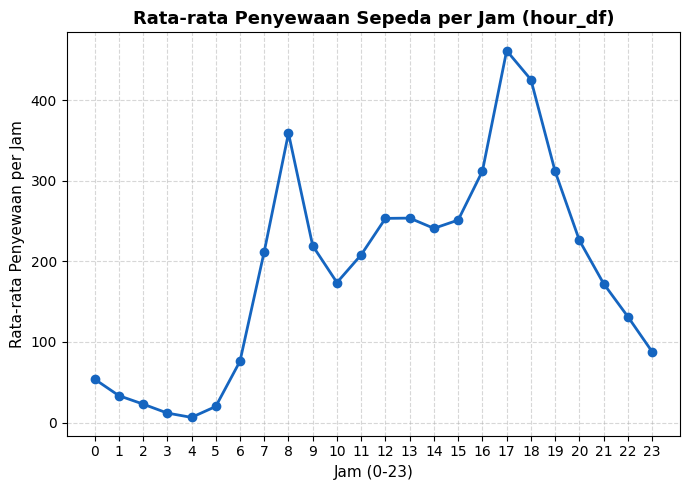

In [67]:
# Visualisasi line chart rata-rata penyewaan per jam (EDA)
plt.figure(figsize=(7, 5))

plt.plot(
    hourly_avg['hr'],
    hourly_avg['cnt'],
    marker='o',
    color='#1565C0',
    linewidth=2
)

plt.title('Rata-rata Penyewaan Sepeda per Jam (hour_df)', fontsize=13, fontweight='bold')
plt.xlabel('Jam (0-23)', fontsize=11)
plt.ylabel('Rata-rata Penyewaan per Jam', fontsize=11)

plt.xticks(range(0, 24))
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:**
- Pola penyewaan sepeda menunjukkan distribusi yang tidak merata sepanjang hari, dengan aktivitas terendah terjadi pada dini hari (sekitar pukul 02.00–04.00), di mana rata-rata penyewaan berada di bawah 25 unit per jam
- Mulai pukul 06.00, terjadi peningkatan signifikan jumlah penyewaan, dengan puncak pertama pada pukul 08.00 (≈ 359 unit), yang menunjukkan adanya jam sibuk pagi
- Setelah mengalami penurunan pada siang hari, jumlah penyewaan kembali meningkat dan mencapai puncak tertinggi pada pukul 17.00 (≈ 461 unit), diikuti oleh pukul 18.00, yang mencerminkan jam sibuk sore
- Setelah pukul 19.00, jumlah penyewaan menurun secara bertahap hingga malam hari, menunjukkan berkurangnya aktivitas pengguna
- Pola dua puncak (pagi dan sore) ini mengindikasikan bahwa sepeda digunakan sebagai sarana transportasi rutin, terutama untuk aktivitas pergi dan pulang kerja (commuting)

In [68]:
# Mengelompokkan data berdasarkan hari dalam seminggu (weekday) dan menghitung rata-rata jumlah penyewaan sepeda (cnt)
weekday_avg_hour = hour_df.groupby('weekday', observed=True)['cnt'].mean()
weekday_avg_hour

,cnt
weekday,
Sun,177.468825
Mon,183.744655
Tue,191.238891
Wed,191.130505
Thu,196.436665
Fri,196.135907
Sat,190.209793


**Insight:**
- Rata-rata penyewaan sepeda per jam relatif stabil sepanjang minggu, dengan nilai berkisar antara sekitar 177 hingga 196 unit per jam
- Hari Kamis (≈ 196) dan Jumat (≈ 196) memiliki rata-rata penyewaan tertinggi, menunjukkan peningkatan aktivitas menjelang akhir hari kerja
- Hari Minggu memiliki rata-rata penyewaan terendah (≈ 177), yang mengindikasikan penurunan aktivitas pada akhir pekan
- Perbedaan antar hari tidak terlalu signifikan, yang menunjukkan bahwa penggunaan sepeda per jam cenderung konsisten sepanjang minggu
- Stabilnya rata-rata penyewaan per jam menunjukkan bahwa pola penggunaan sepeda lebih dipengaruhi oleh waktu dalam sehari (jam) dibandingkan perbedaan hari dalam seminggu
- Meskipun terdapat sedikit peningkatan pada hari kerja, terutama menjelang akhir minggu, perbedaannya tidak sebesar variasi yang terlihat pada analisis per jam
- Hal ini mengindikasikan bahwa faktor seperti jam sibuk (rush hour) memiliki pengaruh yang lebih dominan dibandingkan faktor hari.

In [69]:
# Membuat pivot tabel rata-rata penyewaan per kombinasi jam dan hari (untuk heatmap)
weekday_order_heatmap = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot_hr_weekday = hour_df.groupby(['weekday','hr'], observed=True)['cnt'].mean().unstack()
pivot_hr_weekday.columns = pivot_hr_weekday.columns.astype(int)
pivot_hr_weekday = pivot_hr_weekday.reindex(weekday_order_heatmap)
pivot_hr_weekday

hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
Mon,34.009524,17.307692,10.313131,5.113402,5.785714,21.653846,85.865385,248.538462,412.192308,218.442308,...,192.701923,202.365385,284.451923,502.394231,481.346154,344.576923,242.076923,174.538462,115.759615,65.403846
Tue,27.623762,12.540000,6.801980,4.152174,5.131313,24.455446,106.500000,299.696078,471.784314,236.450980,...,168.365385,186.903846,286.701923,544.278846,517.567308,353.923077,253.192308,186.230769,132.278846,76.173077
Wed,34.557692,15.336538,7.813725,4.888889,4.968750,25.750000,107.807692,303.980769,488.326923,238.528846,...,170.548077,181.288462,272.961538,513.144231,494.029126,357.504854,256.660194,194.669903,143.689320,83.737864
Thu,39.271845,17.223301,9.156863,5.071429,5.280000,25.912621,107.436893,304.737864,488.572816,240.873786,...,177.563107,196.475728,286.298077,527.346154,502.096154,358.451923,268.913462,197.884615,147.240385,96.750000
Fri,52.432692,24.721154,12.740385,6.598039,6.072165,23.903846,90.028846,254.326923,462.278846,258.990385,...,229.365385,252.461538,330.990385,492.413462,420.990385,302.067308,213.326923,169.875000,147.067308,115.211538
Sat,94.304762,67.780952,50.495238,22.885714,7.657143,8.291262,21.000000,45.961905,114.476190,186.790476,...,381.333333,382.428571,366.142857,334.409524,292.048077,239.932692,180.865385,156.000000,139.663462,115.855769
Sun,93.990385,77.432692,61.627451,31.144231,9.362745,8.693878,14.495146,33.104762,83.857143,156.542857,...,363.628571,353.933333,355.400000,318.771429,272.628571,225.476190,168.028571,127.647619,94.123810,61.895238


**Insight:**
- Pada hari kerja (Senin–Jumat), penyewaan menunjukkan pola dua puncak (bimodal), yaitu pada pagi hari sekitar pukul 07.00–08.00 dan sore hari sekitar pukul 17.00–18.00, yang mencerminkan aktivitas komuter (berangkat dan pulang kerja)
- Puncak tertinggi terjadi pada jam pulang kerja (sekitar pukul 17.00–18.00), dengan nilai yang lebih tinggi dibandingkan jam pagi, menunjukkan intensitas penggunaan yang lebih besar pada sore hari
- Sebaliknya, pada akhir pekan (Sabtu dan Minggu), pola penyewaan berubah menjadi lebih merata tanpa puncak tajam di pagi hari, dengan peningkatan penggunaan terjadi pada siang hingga sore hari
- Penyewaan pada akhir pekan cenderung lebih tinggi pada jam siang (sekitar pukul 12.00–15.00), yang mengindikasikan penggunaan untuk aktivitas rekreasi
- Aktivitas penyewaan pada dini hari tetap rendah di semua hari, menunjukkan konsistensi rendahnya permintaan pada periode tersebut

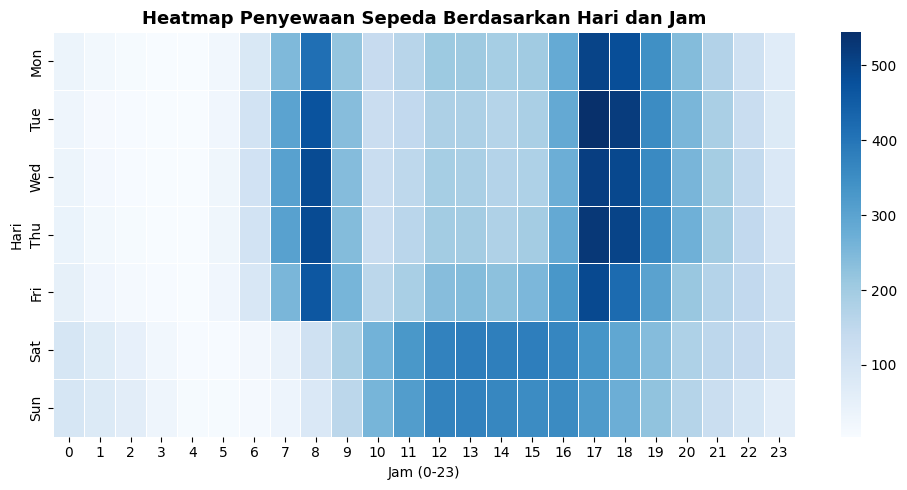

In [70]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot_hr_weekday,
    cmap='Blues',
    linewidths=0.5,
    linecolor='white'
)

plt.title('Heatmap Penyewaan Sepeda Berdasarkan Hari dan Jam', fontsize=13, fontweight='bold')
plt.xlabel('Jam (0-23)')
plt.ylabel('Hari')

plt.tight_layout()
plt.show()

**Insight:**
- Terlihat pola penggunaan sepeda yang berbeda secara jelas antara hari kerja (Senin–Jumat) dan akhir pekan (Sabtu–Minggu)
- Pada hari kerja, terdapat dua puncak penyewaan yang konsisten, yaitu pada pagi hari (sekitar pukul 07.00–08.00) dan sore hari (sekitar pukul 17.00–18.00), yang mencerminkan pola aktivitas komuter
- Puncak sore hari terlihat lebih intens dibandingkan pagi hari, menunjukkan bahwa penggunaan sepeda lebih tinggi saat jam pulang kerja
- Sebaliknya, pada akhir pekan, tidak terlihat puncak tajam di pagi hari. Penyewaan cenderung meningkat secara bertahap dan mencapai puncak pada siang hingga sore hari (sekitar pukul 12.00–16.00)
- Pola ini mengindikasikan bahwa penggunaan sepeda pada akhir pekan lebih bersifat rekreasional dibandingkan kebutuhan transportasi rutin
- Aktivitas penyewaan pada dini hari (00.00–05.00) terlihat rendah di seluruh hari, menunjukkan konsistensi rendahnya permintaan pada jam tersebut

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa penyewaan sepeda dalam beberapa bulan terakhir dan apakah terjadi peningkatan dari tahun 2011 ke 2012?

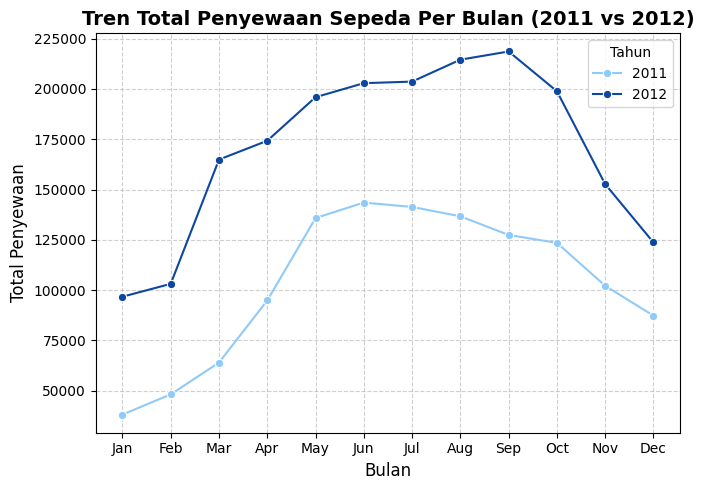

In [71]:
# Visualisasi menggunakan line chart untuk melihat tren pertumbuhan
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=monthly_trend_df,
    x='mnth',
    y='cnt',
    hue='yr',
    marker='o',
    palette={'2011':'#90CAF9', '2012':'#0D47A1'}
)
plt.title("Tren Total Penyewaan Sepeda Per Bulan (2011 vs 2012)", fontsize=14, fontweight='bold')
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Penyewaan", fontsize=12)
plt.legend(title="Tahun")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Insight:**
- Terjadi peningkatan signifikan jumlah penyewaan sepeda pada tahun 2012 dibandingkan 2011 di seluruh bulan
- Pola musiman terlihat konsisten pada kedua tahun, dengan peningkatan mulai awal tahun, mencapai puncak pada pertengahan tahun (Jun–Sep), dan menurun di akhir tahun
- Puncak tertinggi terjadi pada September 2012, menunjukkan periode dengan permintaan paling tinggi
- Meskipun pola serupa, level penyewaan pada tahun 2012 jauh lebih tinggi, mengindikasikan adanya pertumbuhan penggunaan layanan secara keseluruhan

### Pertanyaan 2: Pada musim dan kondisi cuaca apa penyewaan sepeda paling tinggi dan paling rendah selama periode 2011-2012?

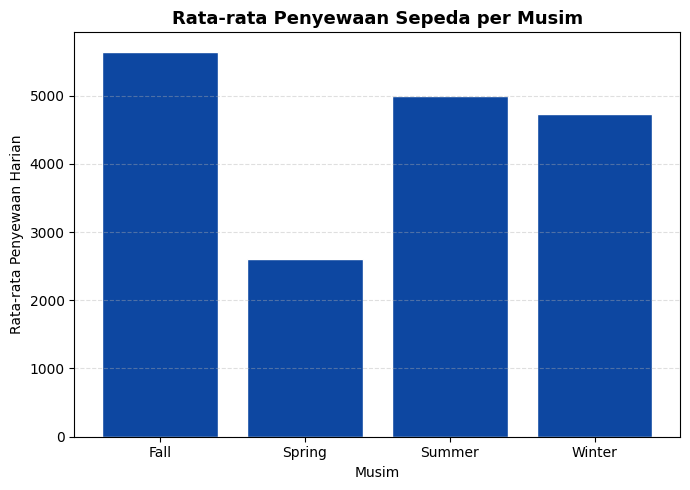

In [72]:
# Visualisasi: Bar chart rata-rata penyewaan sepeda per musim
plt.figure(figsize=(7, 5))

plt.bar(
    season_avg['season'],
    season_avg['avg_cnt'],
    color='#0D47A1',
    edgecolor='white'
)

plt.title('Rata-rata Penyewaan Sepeda per Musim', fontsize=13, fontweight='bold')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Penyewaan Harian')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:**
- Penyewaan sepeda tertinggi terjadi pada musim Fall (≈ 5644 unit/hari), diikuti oleh Summer dan Winter
- Musim Spring memiliki rata-rata penyewaan terendah (≈ 2604 unit/hari), dengan selisih yang cukup signifikan dibandingkan musim lainnya
- Tingginya penyewaan pada musim Fall menunjukkan bahwa kondisi cuaca yang lebih sejuk dan nyaman mendorong aktivitas bersepeda. Sebaliknya, rendahnya penyewaan pada Spring kemungkinan dipengaruhi oleh kondisi cuaca yang masih kurang stabil.

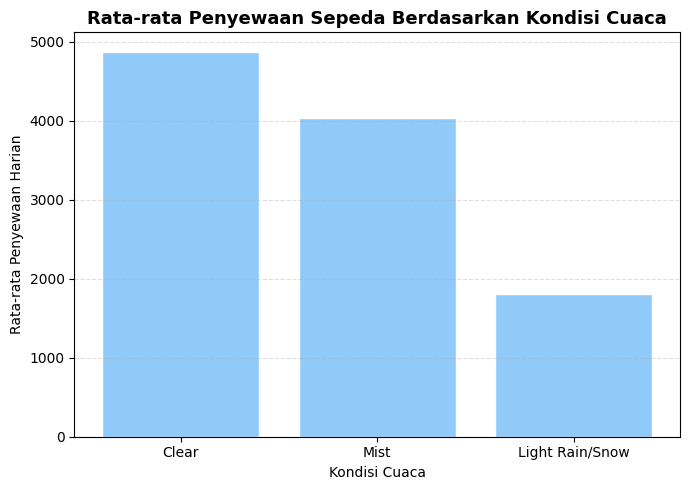

In [73]:
# Visualisasi: Bar chart rata-rata penyewaan sepeda berdasarkan kombinasi musim dan cuaca

plt.figure(figsize=(7, 5))

plt.bar(
    weather_avg['weathersit'],
    weather_avg['avg_cnt'],
    color='#90CAF9',
    edgecolor='white'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca', fontsize=13, fontweight='bold')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan Harian')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:**
- Penyewaan sepeda tertinggi terjadi pada kondisi cuaca Clear (≈ 4877 unit/hari), menunjukkan bahwa cuaca cerah sangat mendukung aktivitas bersepeda
- Pada kondisi Mist, jumlah penyewaan menurun menjadi sekitar 4036 unit/hari, menunjukkan adanya penurunan minat pengguna saat visibilitas berkurang
- Penyewaan terendah terjadi pada kondisi Light Rain/Snow (≈ 1803 unit/hari), yang menunjukkan bahwa cuaca buruk secara signifikan mengurangi penggunaan sepeda
- Perbedaan yang cukup besar antara kondisi Clear dan Light Rain/Snow menunjukkan bahwa faktor cuaca memiliki pengaruh yang kuat terhadap permintaan

### Pertanyaan 3: Pada jam dan hari apa pengguna paling sering melakukan penyewaan sepeda selama periode 2011-2012?

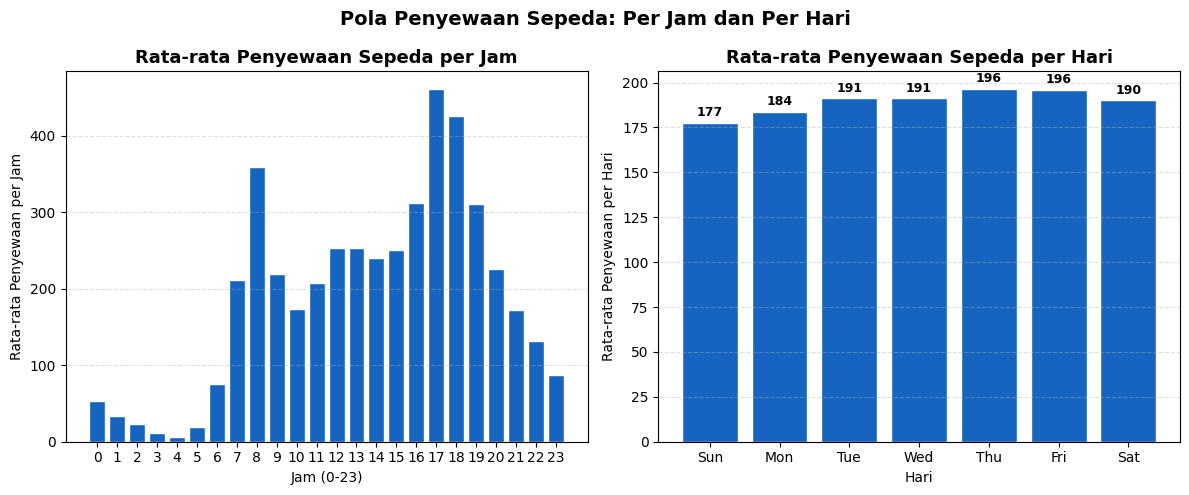

In [74]:
# Visualisasi rata-rata penyewaan per jam dan per hari (angka hanya di hari)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Rata-rata penyewaan per jam (tanpa angka)
axes[0].bar(
    hourly_avg['hr'],
    hourly_avg['cnt'],
    color='#1565C0',
    edgecolor='white'
)

axes[0].set_title('Rata-rata Penyewaan Sepeda per Jam', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jam (0-23)')
axes[0].set_ylabel('Rata-rata Penyewaan per Jam')
axes[0].set_xticks(range(0, 24))
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Plot 2: Rata-rata penyewaan per hari (pakai angka)
weekday_order_list = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']

weekday_avg_sorted = weekday_avg_hour.reset_index()
weekday_avg_sorted['weekday'] = pd.Categorical(
    weekday_avg_sorted['weekday'],
    categories=weekday_order_list,
    ordered=True
)
weekday_avg_sorted = weekday_avg_sorted.sort_values('weekday')

bars = axes[1].bar(
    weekday_avg_sorted['weekday'],
    weekday_avg_sorted['cnt'],
    color='#1565C0',
    edgecolor='white'
)

axes[1].set_title('Rata-rata Penyewaan Sepeda per Hari', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Rata-rata Penyewaan per Hari')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Menambahkan nilai batang di grafik hari
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2, height + 2, f'{height:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.suptitle('Pola Penyewaan Sepeda: Per Jam dan Per Hari', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Penyewaan sepeda paling sering terjadi pada jam 08.00 dan 17.00, yang merupakan jam sibuk (rush hour) ketika pengguna berangkat dan pulang kerja
- Aktivitas penyewaan terendah terjadi pada dini hari (sekitar pukul 00.00–05.00), saat sebagian besar pengguna tidak beraktivitas
- Berdasarkan hari, penyewaan cenderung lebih tinggi pada hari kerja, dengan puncak pada hari Kamis dan Jumat
- Pola ini menunjukkan bahwa sepeda lebih banyak digunakan sebagai sarana transportasi harian (komuter) dibandingkan untuk rekreasi

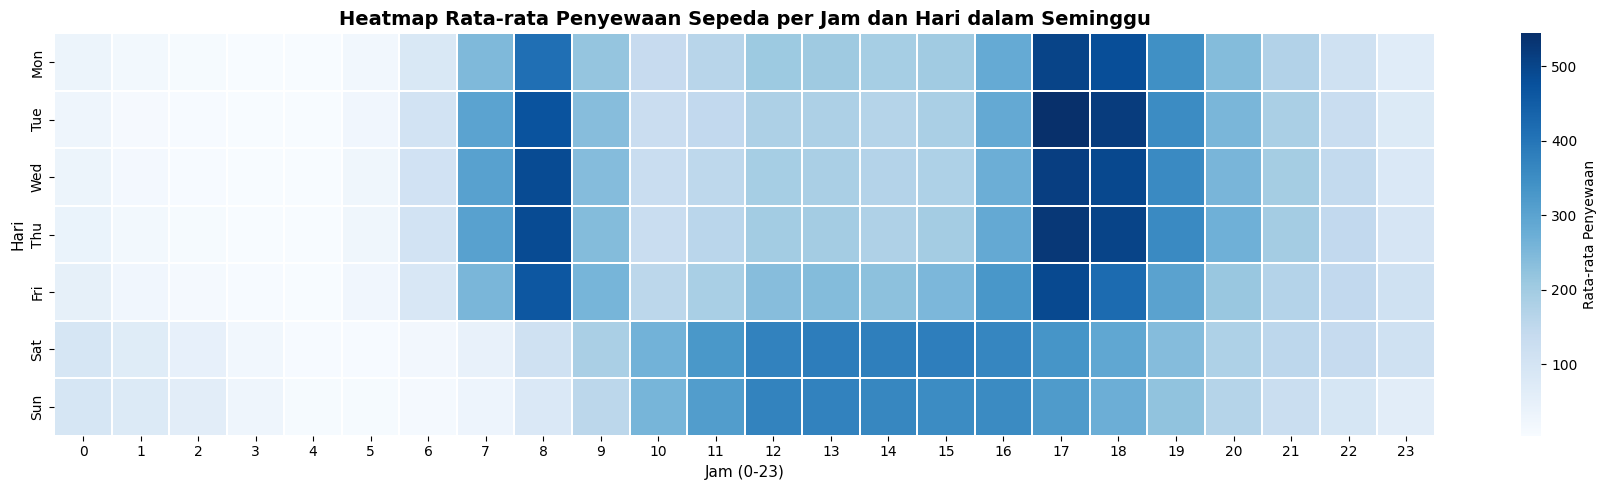

In [75]:
# Visualisasi heatmap rata-rata penyewaan per kombinasi jam dan hari
plt.figure(figsize=(18, 5))
sns.heatmap(
    pivot_hr_weekday,
    cmap='Blues',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Rata-rata Penyewaan'},
    annot=False
)
plt.title('Heatmap Rata-rata Penyewaan Sepeda per Jam dan Hari dalam Seminggu',
          fontsize=14, fontweight='bold')
plt.xlabel('Jam (0-23)', fontsize=11)
plt.ylabel('Hari', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:**
- Heatmap menunjukkan bahwa penyewaan sepeda paling sering terjadi pada hari kerja (Senin–Jumat), terutama pada jam sibuk pagi (07.00–09.00) dan sore (16.00–19.00)
- Intensitas tertinggi (warna paling gelap) terlihat pada jam 17.00–18.00 di hari kerja, khususnya sekitar Selasa hingga Kamis, yang menandakan waktu dengan permintaan paling tinggi sepanjang minggu
- Pada pagi hari (sekitar 08.00) juga terjadi lonjakan signifikan di hari kerja, namun tidak setinggi sore hari, menunjukkan pola aktivitas berangkat kerja. Sebaliknya, akhir pekan (Sabtu–Minggu) tidak memiliki lonjakan tajam di pagi atau sore hari. Penyewaan cenderung lebih tinggi dan merata pada siang hari (10.00–16.00), namun tetap lebih rendah dibandingkan puncak di hari kerja.

## Analisis Lanjutan (Opsional)

Manual Grouping: Segmentasi Hari Berdasarkan Pola Penggunaan

In [76]:
# Manual Grouping: Mengelompokkan hari berdasarkan jenis penggunaan
# Logika bisnis: Hari kerja = potensi komuter, Akhir pekan = potensi rekreasi

def classify_day_type(row):
    if row['holiday'] == 1:
        return 'Hari Libur'
    elif row['workingday'] == 1:
        return 'Hari Kerja'
    else:
        return 'Akhir Pekan'

day_df['day_type'] = day_df.apply(classify_day_type, axis=1)

# Melihat distribusi tipe hari
day_df['day_type'].value_counts()

,count
day_type,
Hari Kerja,500
Akhir Pekan,210
Hari Libur,21


**Insight:**
- Dataset didominasi oleh Hari Kerja (500 hari), jauh lebih banyak dibandingkan Akhir Pekan (210 hari) dan Hari Libur (21 hari). Hal ini menunjukkan bahwa sebagian besar aktivitas penyewaan terjadi dalam konteks hari kerja
- Jumlah Hari Libur sangat kecil, sehingga analisis pada kategori ini perlu dilakukan dengan hati-hati karena representasinya terbatas dan berpotensi kurang stabil
- Pembagian ini mengindikasikan adanya tiga pola penggunaan utama, yaitu:
  - Hari Kerja potensi penggunaan untuk aktivitas komuter (kerja/sekolah)
  - Akhir Pekan : potensi penggunaan untuk rekreasi
  - Hari Libur : pola campuran (bisa rekreasi atau aktivitas khusus)

In [77]:
# Menghitung rata-rata penyewaan untuk setiap tipe hari
day_type_stats = day_df.groupby('day_type')['cnt'].agg(['mean','median','std','min','max']).reset_index()
day_type_stats.columns = ['Tipe Hari', 'Rata-rata', 'Median', 'Std Dev', 'Min', 'Maks']
day_type_stats = day_type_stats.round(0)
day_type_stats

,Tipe Hari,Rata-rata,Median,Std Dev,Min,Maks
0,Akhir Pekan,4390.0,4468.0,2043.0,605,8714
1,Hari Kerja,4585.0,4582.0,1878.0,22,8362
2,Hari Libur,3735.0,3351.0,2103.0,1000,7403


**Insight:**
- Hari Kerja memiliki rata-rata penyewaan tertinggi (4.585 unit/hari), sedikit lebih tinggi dibandingkan Akhir Pekan (4.390 unit/hari). Hal ini menunjukkan bahwa aktivitas penyewaan lebih didominasi oleh kebutuhan rutin seperti komuter (kerja/sekolah)
- Akhir Pekan tetap memiliki angka penyewaan yang tinggi, meskipun sedikit lebih rendah dari hari kerja, yang mengindikasikan penggunaan untuk aktivitas rekreasi tetap signifikan
- Hari Libur memiliki rata-rata penyewaan terendah (3.735 unit/hari), menunjukkan bahwa meskipun termasuk waktu luang, aktivitas penyewaan tidak setinggi akhir pekan biasa kemungkinan karena faktor lain seperti perjalanan keluar kota atau aktivitas non-rutin
- Variasi (Std Dev) tertinggi terdapat pada Hari Libur (2103), yang menunjukkan bahwa penyewaan pada hari libur cenderung lebih tidak stabil dan fluktuatif dibandingkan hari lainnya
- Nilai minimum yang sangat rendah pada Hari Kerja (22 unit) menunjukkan adanya hari-hari tertentu dengan permintaan sangat rendah (kemungkinan faktor cuaca ekstrem atau kondisi khusus)

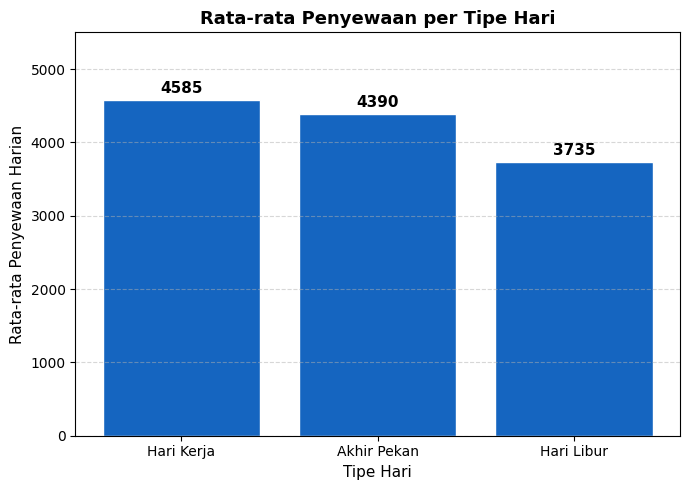

In [78]:
# Visualisasi rata-rata penyewaan per hari
day_type_order = ['Hari Kerja', 'Akhir Pekan', 'Hari Libur']
day_type_avg = day_df.groupby('day_type')['cnt'].mean().reindex(day_type_order)

plt.figure(figsize=(7, 5))
bars = plt.bar(
    day_type_avg.index,
    day_type_avg.values,
    color='#1565C0',
    edgecolor='white'
)

plt.title('Rata-rata Penyewaan per Tipe Hari', fontsize=13, fontweight='bold')
plt.xlabel('Tipe Hari', fontsize=11)
plt.ylabel('Rata-rata Penyewaan Harian', fontsize=11)

for bar, val in zip(bars, day_type_avg.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{val:.0f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, day_type_avg.max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight:**
- Hari Kerja memiliki rata-rata penyewaan tertinggi (~4.585 unit/hari) dibandingkan tipe hari lainnya, menunjukkan bahwa penggunaan sepeda lebih banyak didorong oleh aktivitas rutin seperti bekerja atau sekolah (komuter)
- Akhir Pekan (~4.390 unit/hari) memiliki tingkat penyewaan yang sedikit lebih rendah, namun tetap tinggi, yang mengindikasikan bahwa sepeda juga banyak digunakan untuk aktivitas rekreasi
- Hari Libur (~3.735 unit/hari) memiliki rata-rata penyewaan paling rendah, menunjukkan bahwa tidak semua hari libur meningkatkan penggunaan sepeda—kemungkinan karena pengguna memiliki alternatif aktivitas lain
- Perbedaan antara Hari Kerja dan Akhir Pekan tidak terlalu besar, menandakan bahwa layanan sepeda tetap memiliki permintaan yang stabil sepanjang minggu, meskipun dengan tujuan penggunaan yang berbeda

Binning: Segmentasi Penyewaan Harian ke dalam Kategori Volume

In [79]:
# Binning: Membagi penyewaan harian (cnt) ke dalam 4 kategori volume
# Menggunakan pd.qcut untuk membagi ke dalam kuartil yang seimbang
day_df['rental_category'] = pd.qcut(
    day_df['cnt'],
    q=4,
    labels=['Sangat Rendah', 'Rendah', 'Tinggi', 'Sangat Tinggi']
)

# Melihat distribusi dan batas interval tiap kategori
print("Distribusi Kategori Penyewaan:")
print(day_df['rental_category'].value_counts().sort_index())
print()
print("Batas Interval:")
print(pd.qcut(day_df['cnt'], q=4, retbins=True)[1])

Distribusi Kategori Penyewaan:
rental_category
Sangat Rendah    183
Rendah           183
Tinggi           182
Sangat Tinggi    183
Name: count, dtype: int64

Batas Interval:
[  22. 3152. 4548. 5956. 8714.]


**Insight:**
- Data penyewaan berhasil dibagi menjadi 4 kategori dengan distribusi yang hampir seimbang (~182–183 data per kategori), menunjukkan bahwa metode qcut (kuartil) efektif dalam membagi data secara proporsional.
- Rentang jumlah penyewaan harian terbagi sebagai berikut:
  - Sangat Rendah: ≤ 3.152 unit/hari
  - Rendah: 3.152 – 4.548 unit/hari
  - Tinggi: 4.548 – 5.956 unit/hari
  - Sangat Tinggi: > 5.956 unit/hari
- Perbedaan interval antar kategori menunjukkan bahwa variasi jumlah penyewaan cukup besar, dengan rentang dari 22 hingga 8.714 unit/hari
- Kategori Sangat Tinggi memiliki threshold yang cukup tinggi (> 5.956), yang mengindikasikan bahwa hari-hari dengan permintaan sangat tinggi hanya terjadi pada kondisi tertentu (misalnya cuaca baik atau musim tertentu)

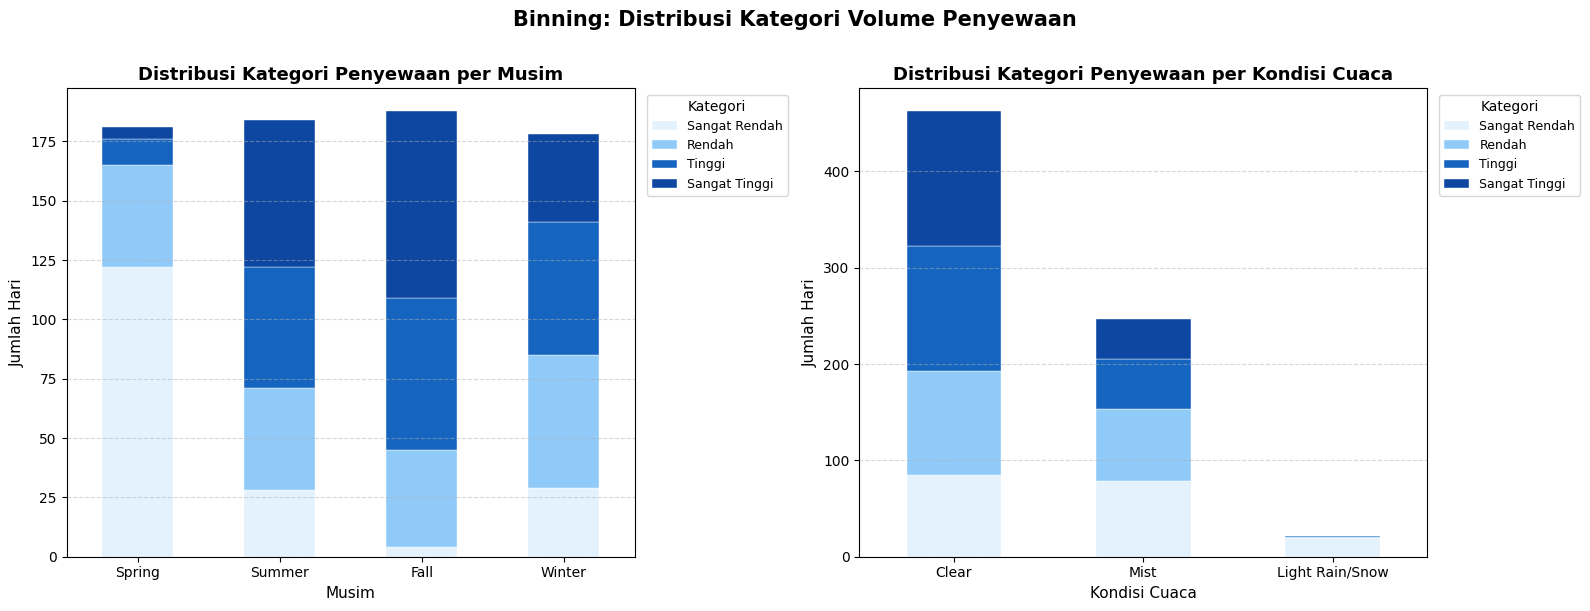

In [80]:
# Visualisasi binning: distribusi kategori per musim dan per cuaca
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gradasi biru 4 kategori: Sangat Rendah (paling muda) hingga Sangat Tinggi (paling gelap)
category_colors = ['#E3F2FD', '#90CAF9', '#1565C0', '#0D47A1']

# Stacked bar: distribusi kategori per musim
season_rental_dist = day_df.groupby(['season', 'rental_category'], observed=True).size().unstack(fill_value=0)
season_order_list = ['Spring', 'Summer', 'Fall', 'Winter']
season_rental_dist = season_rental_dist.reindex(season_order_list)

season_rental_dist.plot(kind='bar', stacked=True, ax=axes[0], color=category_colors,
                        edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribusi Kategori Penyewaan per Musim', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Musim', fontsize=11)
axes[0].set_ylabel('Jumlah Hari', fontsize=11)
axes[0].legend(title='Kategori', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Stacked bar: distribusi kategori per kondisi cuaca
weather_rental_dist = day_df.groupby(['weathersit', 'rental_category'], observed=True).size().unstack(fill_value=0)
weather_order_list = ['Clear', 'Mist', 'Light Rain/Snow']
weather_rental_dist = weather_rental_dist.reindex(weather_order_list)

weather_rental_dist.plot(kind='bar', stacked=True, ax=axes[1], color=category_colors,
                         edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribusi Kategori Penyewaan per Kondisi Cuaca', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca', fontsize=11)
axes[1].set_ylabel('Jumlah Hari', fontsize=11)
axes[1].legend(title='Kategori', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Binning: Distribusi Kategori Volume Penyewaan', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight:**
- Distribusi per musim menunjukkan pola yang sangat jelas:
  - Fall dan Summer didominasi kategori “Tinggi” dan “Sangat Tinggi”, menandakan bahwa sebagian besar hari di musim ini memiliki volume penyewaan tinggi
  - Spring didominasi kategori “Sangat Rendah” dan “Rendah”, menunjukkan bahwa permintaan masih rendah di awal tahun
  - Winter berada di tengah, dengan kombinasi kategori rendah hingga tinggi, tetapi tidak sekuat Fall/Summer.
- Distribusi per kondisi cuaca memperkuat pola ini:
  - Cuaca Clear memiliki proporsi terbesar pada kategori “Tinggi” dan “Sangat Tinggi”, menunjukkan bahwa hari-hari dengan cuaca cerah hampir selalu menghasilkan penyewaan tinggi
  - Cuaca Mist cenderung tersebar di kategori menengah, artinya permintaan masih ada tetapi tidak optimal
  - Light Rain/Snow hampir seluruhnya berada di kategori rendah, menandakan bahwa cuaca buruk sangat membatasi aktivitas penyewaan

## Conclusion

Berdasarkan hasil analisis data penyewaan sepeda, diperoleh beberapa kesimpulan utama sebagai berikut:

1. Performa Penyewaan dan Tren Tahunan
Terjadi peningkatan signifikan jumlah penyewaan sepeda dari tahun 2011 ke 2012 di seluruh bulan. Sebagai contoh, pada bulan September jumlah penyewaan meningkat dari sekitar 127.418 unit (2011) menjadi 218.573 unit (2012). Pola musiman juga terlihat jelas, di mana penyewaan terendah terjadi pada awal tahun seperti Januari (≈ 2.176 unit/hari), dan mencapai puncak pada periode Juni–September (hingga ≈ 5.900 unit/hari). Hal ini menunjukkan adanya tren pertumbuhan sekaligus pengaruh musim terhadap permintaan.
2. Pengaruh Musim dan Kondisi Cuaca
Penyewaan sepeda tertinggi terjadi pada musim Fall dengan rata-rata sekitar 5.644 unit/hari, diikuti Summer (≈ 4.992 unit/hari), sedangkan terendah terjadi pada Spring (≈ 2.604 unit/hari). Dari sisi cuaca, kondisi Clear menghasilkan rata-rata penyewaan tertinggi (≈ 4.876 unit/hari), diikuti Mist (≈ 4.035 unit/hari), dan terendah pada Light Rain/Snow (≈ 1.803 unit/hari).
Hal ini menunjukkan bahwa kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan, bahkan lebih langsung dibandingkan musim.
3. Pola Penggunaan Berdasarkan Waktu (Jam dan Hari)
Pola penyewaan menunjukkan dua puncak utama dalam sehari, yaitu pada pagi hari sekitar pukul 08.00 (≈ 359 unit/jam) dan sore hari pukul 17.00 (≈ 461 unit/jam) sebagai titik tertinggi. Rata-rata penyewaan harian tertinggi terjadi pada hari Jumat (≈ 4.690 unit/hari) dan terendah pada hari Minggu (≈ 4.228 unit/hari), meskipun perbedaannya tidak terlalu besar. Pola ini menunjukkan bahwa penggunaan sepeda didominasi oleh aktivitas komuter pada hari kerja, sementara akhir pekan cenderung digunakan untuk aktivitas rekreasi dengan distribusi waktu yang lebih merata.

## Recommendation

Berdasarkan kesimpulan tersebut, berikut beberapa rekomendasi yang dapat dilakukan:

1. Optimasi operasional berdasarkan jam sibuk
menambah ketersediaan sepeda pada jam puncak, khususnya pukul 07.00–09.00 dan 16.00–18.00, untuk mengakomodasi lonjakan permintaan pengguna.
2. Strategi berbasis musim dan cuaca
meningkatkan kapasitas layanan pada musim dengan permintaan tinggi seperti Fall dan Summer, serta saat cuaca cerah. Pada kondisi cuaca buruk (Light Rain/Snow), operasional dapat dioptimalkan untuk efisiensi.
3. Program promosi pada periode permintaan rendah
memberikan insentif atau promosi pada musim Spring dan saat cuaca kurang mendukung guna meningkatkan jumlah penyewaan.
4. Program promosi pada periode permintaan rendah
segmentasi pengguna untuk layanan yang lebih Tepat sasaran
mengembangkan layanan berbasis kebutuhan pengguna, seperti paket langganan untuk komuter (hari kerja) dan promo khusus rekreasi pada akhir pekan.